In [12]:
data = {
    "study_hours": [
        1.5, 2.0, None, 2.8, 3.2, 3.5, 3.8, 4.0, 4.2, 4.5, 4.8, 5.0,
        5.2, None, 5.8, 6.0, 6.2, 6.5, 6.8, 7.0, 7.2, 7.5, None, 8.0,
        8.2, 8.5, 8.8, 9.0, 9.2, 9.5, 9.8, 10.0, 10.2, 10.5, 10.8, 11.0
    ],
    "attendance": [
        62, 58, 70, 65, None, 74, 68, 79, 88, 71, 85, 90,
        73, 86, 78, 92, 80, 84, 89, None, 91, 83, 95, 87,
        94, 88, 96, 92, 85, 97, 90, 98, None, 99, 93, 96
    ],
    "assignment_score": [
        55, 62, 58, 70, 64, 78, None, 72, 81, 68, 75, 84,
        69, 88, 76, 80, 85, 79, 92, 82, 86, None, 83, 94,
        87, 91, 89, 95, 88, 92, 96, 93, 97, 95, None, 96
    ],
    "final_marks": [
        38, 35, 42, 44, 51, 53, 48, 56, 62, None, 60, 67,
        58, 69, 64, 72, 68, 71, 76, 70, 78, 77, 83, 81,
        84, None, 88, 90, 86, 93, 92, 95, 94, 97, 96, 98
    ]
}

In [51]:
import pandas as pd
import numpy as np

In [14]:
df = pd.DataFrame(data).to_csv('students.csv')

In [15]:
df = pd.read_csv('students.csv')

In [16]:
# Some tests on the data first

In [17]:
df.describe()

,Unnamed: 0,study_hours,attendance,assignment_score,final_marks
count,36.000000,33.000000,33.000000,33.000000,34.000000
mean,17.500000,6.696970,84.121212,81.818182,71.647059
std,10.535654,2.729524,11.098304,11.764498,18.527428
min,0.000000,1.500000,58.000000,55.000000,35.000000
25%,8.750000,4.500000,78.000000,75.000000,58.500000
50%,17.500000,6.800000,87.000000,84.000000,71.500000
75%,26.250000,9.000000,92.000000,92.000000,87.500000
max,35.000000,11.000000,99.000000,97.000000,98.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        36 non-null     int64  
 1   study_hours       33 non-null     float64
 2   attendance        33 non-null     float64
 3   assignment_score  33 non-null     float64
 4   final_marks       34 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.5 KB


In [19]:
print(df.isnull().sum())

Unnamed: 0          0
study_hours         3
attendance          3
assignment_score    3
final_marks         2
dtype: int64


In [22]:
df = df.fillna(df.ffill())

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        36 non-null     int64  
 1   study_hours       36 non-null     float64
 2   attendance        36 non-null     float64
 3   assignment_score  36 non-null     float64
 4   final_marks       36 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.5 KB


In [24]:
# Correlation analysis

In [26]:
predictors = df[["study_hours", "attendance", "assignment_score"]]

In [27]:
corr_matrix = predictors.corr()
print(corr_matrix)

                  study_hours  attendance  assignment_score
study_hours          1.000000    0.861363          0.905277
attendance           0.861363    1.000000          0.869312
assignment_score     0.905277    0.869312          1.000000


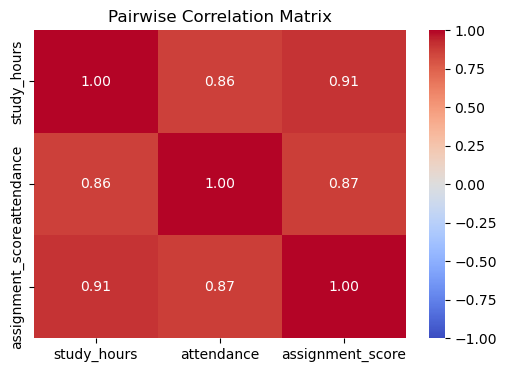

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Pairwise Correlation Matrix")
plt.show()

In [31]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [32]:
X = add_constant(predictors)

In [33]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [34]:
vif_summary = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)
print(vif_summary)

            Feature       VIF
0       study_hours  6.336397
1        attendance  4.680994
2  assignment_score  6.693205


In [39]:
x = df.iloc[:, 1:4]
y = df['final_marks']

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)

In [44]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
print("Model Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

Model Intercept:  3.086289177928805
Coefficients:  [4.92103836 0.3762238  0.06278719]


In [49]:
coeff_table = pd.DataFrame({
    'Feature': x.columns,
    'Coefficients': model.coef_
})
coeff_table

,Feature,Coefficients
0,study_hours,4.921038
1,attendance,0.376224
2,assignment_score,0.062787


In [46]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [50]:
y_pred = model.predict(x_test)

In [52]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  2.1367157712081273
MSE:  8.243872191065618
RMSE:  2.87121441050048
R2:  0.976691649574651


In [54]:
new_student = pd.DataFrame({
    "study_hours": [9],
    "attendance": [90],
    "assignment_score": [89]
})

In [55]:
preds = model.predict(new_student)

In [56]:
preds

array([86.82383643])

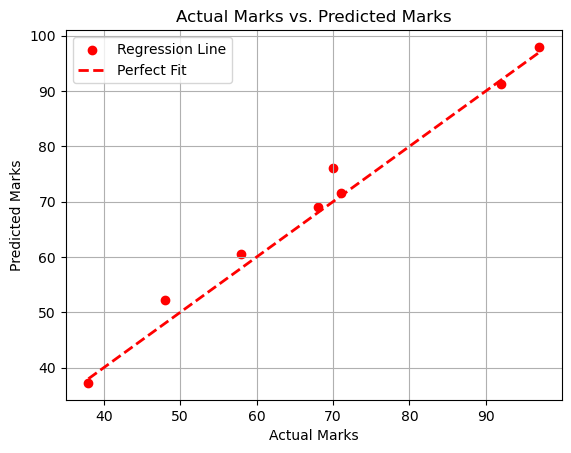

In [63]:
#plt.scatter(x_train.values, y_train, color="blue", label="Actual data")
plt.scatter(y_test, y_pred, color="red", label="Regression Line")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Marks vs. Predicted Marks")
plt.legend()
plt.grid(True)
plt.show()

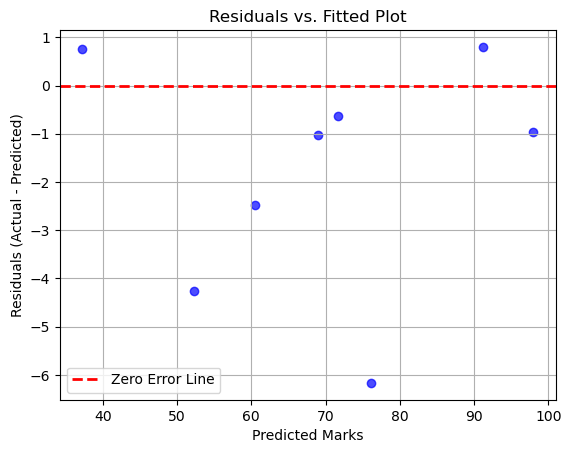

In [64]:
import matplotlib.pyplot as plt

# Compute residuals
residuals = y_test - y_pred

# Scatter plot of predicted values vs residuals
plt.scatter(y_pred, residuals, color='blue', alpha=0.7)

# The axhline adds a horizontal reference line across the axis at y = 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.xlabel('Predicted Marks')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Fitted Plot')
plt.legend()
plt.grid(True)
plt.show()